<a href="https://colab.research.google.com/github/Nmg1994/ActiveTransportation/blob/main/ABM_ActiveTransportation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Latest Version of the Agent-Based Transportation Model: GitHub–Google Colab Integration and Synchronization Workflow

In [ ]:
!pip install mesa
!pip install osmnx

In [2]:
from mesa import Model, Agent
from mesa.datacollection import DataCollector
from mesa.time import Schedule
import os

import geopandas as gpd
import networkx as nx
import osmnx
import numpy as np
import random
from shapely.geometry import Point
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.optimize import minimize
import pandas as pd
from matplotlib.patches import Patch
import matplotlib.pyplot as plt


# Importing spatial data

In [4]:
data_path = os.environ.get("DATA_FOLDER", "/content/drive/MyDrive/Transportation_UrbanHealth")
montreal_da = gpd.read_file(os.path.join(data_path, "Montreal_DA_MTM.shp"))
schools = gpd.read_file(os.path.join(data_path, "Schools_MTM.shp"))
residential = gpd.read_file(os.path.join(data_path, "Residential_MTM.shp"))
workplaces = gpd.read_file(os.path.join(data_path, "Workplaces_MTM.shp"))
bixi = gpd.read_file(os.path.join(data_path, "Bixi_station_MTM.shp"))
stm = gpd.read_file(os.path.join(data_path, "STM_MTM.shp"))
Netnodes = gpd.read_file(os.path.join(data_path, "Nodes.shp"))
#Netedges = gpd.read_file(os.path.join(data_path, "Edges.shp"))
Netedges_car = gpd.read_file(os.path.join(data_path, "Edges_car.shp"))
Netedges_walk = gpd.read_file(os.path.join(data_path, "Edges_walk.shp"))
Netedges_bike = gpd.read_file(os.path.join(data_path, "Edges_bike.shp"))
Netedges_transit = gpd.read_file(os.path.join(data_path, "Edges_transit.shp"))


In [11]:
len(montreal_da[montreal_da['Car_truck_'] > montreal_da['Bicycle']])

3181

In [12]:
len(montreal_da[montreal_da['Car_truck_'] <= montreal_da['Bicycle']])

47

In [13]:
montreal_da['Car_truck_']

,Car_truck_
0,240
1,160
2,70
3,105
4,90
...,...
3223,60
3224,0
3225,185
3226,180


# Creating Networks

## Building car network using OSMnx

In [5]:
# Formatting nodes and edges to match OSMnx requirements
nodex = Netnodes.join(Netnodes.get_coordinates()).set_index('nodeid')[['x', 'y', 'geometry']]
nodex.index.name = 'osmid'

edgex_car = Netedges_car.set_index(['u', 'v', 'key']).rename(columns={'edgeid': 'osmid'})

# Load network
netx_car = osmnx.convert.graph_from_gdfs(nodex, edgex_car)

## Building walk network using OSMnx

In [6]:
# Formatting nodes and edges to match OSMnx requirements
edgex_walk = Netedges_walk.set_index(['u', 'v', 'key']).rename(columns={'edgeid': 'osmid'})

#Load network
netx_walk = osmnx.convert.graph_from_gdfs(nodex, edgex_walk)

## Building the bike network using OSMnx

In [7]:
# Formatting nodes and edges to match OSMnx requirements
edgex_bike = Netedges_bike.set_index(['u', 'v', 'key']).rename(columns={'edgeid': 'osmid'})

#Load network
netx_bike = osmnx.convert.graph_from_gdfs(nodex, edgex_bike)

## Building public transportation network

In [8]:
edgex_transit = Netedges_transit.set_index(['u', 'v', 'key']).rename(columns={'edgeid': 'osmid'})

#Load network
netx_transit = osmnx.convert.graph_from_gdfs(nodex, edgex_transit)

# Plotting Network

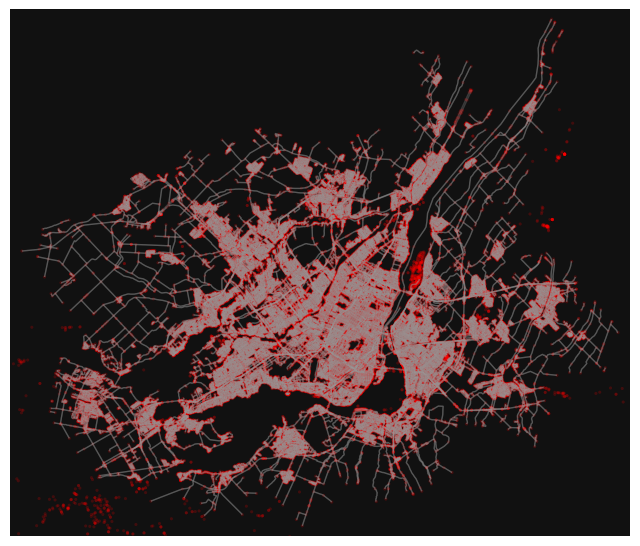

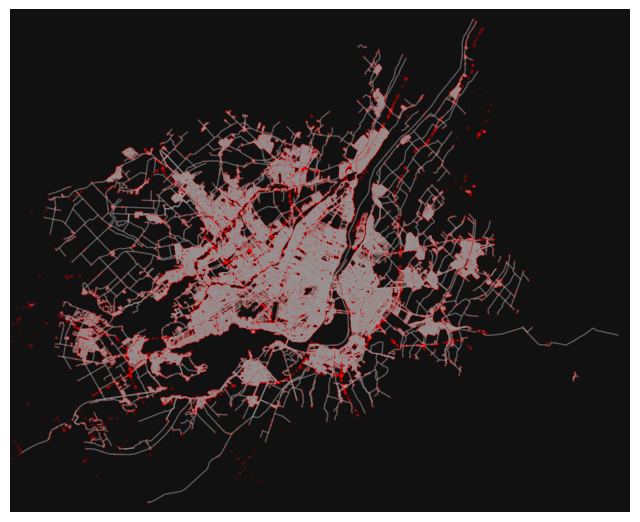

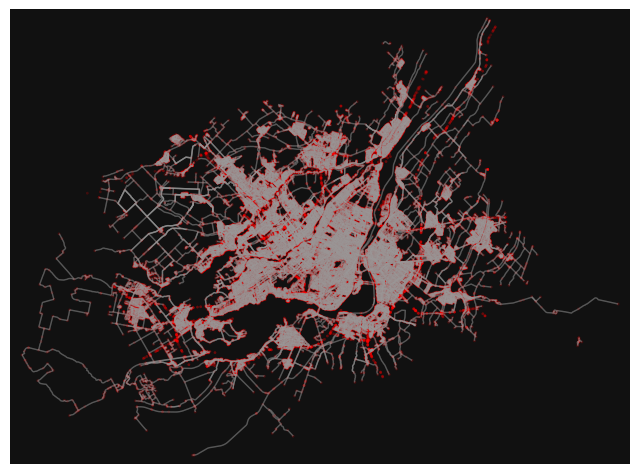

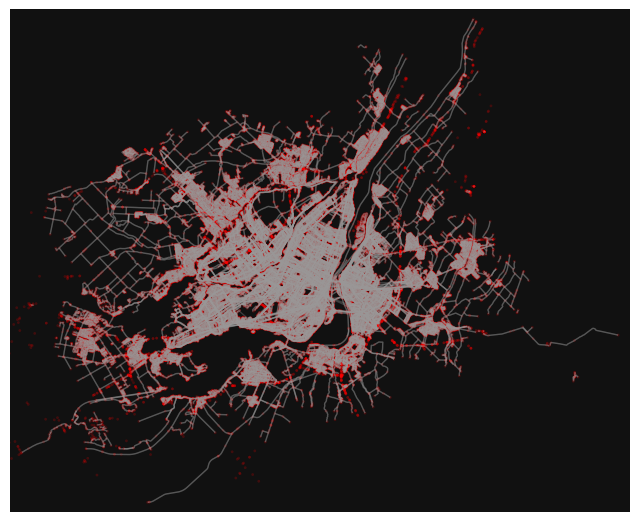

In [ ]:
# Car network
fig, ax = osmnx.plot.plot_graph(netx_car, edge_alpha=.3, node_color="r", node_size=5, node_zorder=0, node_alpha=.2)

# Walk network
fig, ax = osmnx.plot.plot_graph(netx_walk, edge_alpha=.3, node_color="r", node_size=4, node_zorder=0, node_alpha=.2)

# Bike network
fig, ax = osmnx.plot.plot_graph(netx_bike, edge_alpha=.3, node_color="r", node_size=4, node_zorder=0, node_alpha=.2)

# Transit network
fig, ax = osmnx.plot.plot_graph(netx_transit, edge_alpha=.3, node_color="r", node_size=4, node_zorder=0, node_alpha=.2)

# Model development

In [ ]:
# The main function
class TransportModel(Model):

  def __init__(self, n_rep, Net_car, Net_walk, Net_bike, Net_transit, Wrk_N, Schls_N, BiXi_N, STM_N):
    super().__init__()
    self.agent_list = []
    self.Each_agent_represents = n_rep
    self.montreal_da = gpd.read_file(os.path.join(data_path, "Montreal_DA_MTM.shp"))
    self.residential = gpd.read_file(os.path.join(data_path, "Residential_MTM.shp"))

    schools_with_da = gpd.sjoin(Schls_N, self.montreal_da[["DA_name", "geometry"]], how="left", predicate="intersects")

    self.Gc = Net_car
    self.Gw = Net_walk
    self.Gb = Net_bike
    self.Gstm = Net_transit

    self.workplaces = Wrk_N
    self.schools = schools_with_da
    self.bixis = BiXi_N
    self.stms = STM_N

    # Add network nodes

    self.bixis['network_node'] = osmnx.distance.nearest_nodes(self.Gb, self.bixis.geometry.x, self.bixis.geometry.y)
    self.stms['network_node'] = osmnx.distance.nearest_nodes(self.Gstm, self.stms.geometry.x, self.stms.geometry.y)

    self.bixi_tree = cKDTree(np.column_stack([self.bixis.geometry.x, self.bixis.geometry.y]))
    self.stm_tree = cKDTree(np.column_stack([self.stms.geometry.x, self.stms.geometry.y]))

    #----------------------------------------------------------------------
    # Residential
    self.residential["res_id"] = np.arange(len(self.residential))

    x = self.residential.centroid.x.values
    y = self.residential.centroid.y.values

    self.residential["node_Gc"] = osmnx.distance.nearest_nodes(self.Gc, x, y)
    self.residential["node_Gw"] = osmnx.distance.nearest_nodes(self.Gw, x, y)
    self.residential["node_Gb"] = osmnx.distance.nearest_nodes(self.Gb, x, y)
    self.residential["node_Gstm"] = osmnx.distance.nearest_nodes(self.Gstm, x, y)

    self.res_lookup = (self.residential.set_index("res_id")[["node_Gc","node_Gw","node_Gb","node_Gstm"]].to_dict("index"))
    #----------------------------------------------------------------------
    # Workplaces
    self.workplaces["wrk_id"] = np.arange(len(self.workplaces))

    xw = self.workplaces.centroid.x.values
    yw = self.workplaces.centroid.y.values

    self.workplaces["node_Gc"] = osmnx.distance.nearest_nodes(self.Gc, xw, yw)
    self.workplaces["node_Gw"] = osmnx.distance.nearest_nodes(self.Gw, xw, yw)
    self.workplaces["node_Gb"] = osmnx.distance.nearest_nodes(self.Gb, xw, yw)
    self.workplaces["node_Gstm"] = osmnx.distance.nearest_nodes(self.Gstm, xw, yw)

    self.wrk_lookup = (self.workplaces.set_index("wrk_id")[["node_Gc","node_Gw","node_Gb","node_Gstm"]].to_dict("index"))
    #----------------------------------------------------------------------
    self.schools["school_id"] = np.arange(len(self.schools))

    xs = self.schools.centroid.x.values
    ys = self.schools.centroid.y.values

    self.schools["node_Gc"] = osmnx.distance.nearest_nodes(self.Gc, xs, ys)
    self.schools["node_Gw"] = osmnx.distance.nearest_nodes(self.Gw, xs, ys)
    self.schools["node_Gb"] = osmnx.distance.nearest_nodes(self.Gb, xs, ys)
    self.schools["node_Gstm"] = osmnx.distance.nearest_nodes(self.Gstm, xs, ys)

    self.school_lookup = (self.schools.set_index("school_id")[["node_Gc","node_Gw","node_Gb","node_Gstm"]].to_dict("index"))
    #-----------------------------------------------------------------------------------------
    # Create agents
    self.create_agents()

    # Data collection
    self.datacollector = DataCollector(
        agent_reporters={
            "DA_ID": "DA_ID",
            "age": "age",
            "income": "income",
            "time_home_work_car": "time_home_work_car",
            "time_home_stm": "time_home_stm",
            "time_stm_stm": "time_stm_stm",
            "time_stm_work": "time_stm_work",
            "time_home_bixi": "time_home_bixi",
            "time_bixi_bixi": "time_bixi_bixi",
            "time_bixi_work": "time_bixi_work",
            "time_home_work_walk": "time_home_work_walk",
            "bike_lane_length": "bike_lane_length",
            "bixi_density": "bixi_density",
            "mode_choice": "mode_choice"
        }
    )


  def closest_candidate_node(self, G, source_node, candidate_gdf, tree):

    source_xy = (
        G.nodes[source_node]['x'],
        G.nodes[source_node]['y']
    )

    distance, idx = tree.query(source_xy)
    return candidate_gdf.iloc[idx]['network_node']

  # --------------------------------------------------------
  def bixi_density_within_radius(self, G, source_node, bixis, radius, weight='length'):
    # shortest paths from source_node
    lengths = nx.single_source_dijkstra_path_length(G, source_node, weight=weight)

    # count reachable BIXI nodes within radius
    nearby_bixi = [
        node for node in bixis
        if node in lengths and lengths[node] <= radius
    ]
    return len(nearby_bixi)
  # --------------------------------------------------------
  def create_agents(self):

    pbar = tqdm(self.montreal_da.iterrows(), total=len(self.montreal_da))
    for _, da in pbar:
      pbar.set_description(f"Creating agents for DA: {da['DA_name']}")

      if da['Car_truck_'] == 0 and da['Public_tra'] == 0 and da['Bicycle'] == 0 and da['Walked'] == 0:
        continue

      else:
        # Residential polygons inside this DA
        res = self.residential[self.residential.intersects(da.geometry)]
        if res.empty:
          continue

        income_val = 0
        # Handle income with zero
        if da['Median_tot'] != 0:
            income_val = da['Median_tot']
        else:
            income_val = self.montreal_da[self.montreal_da['Median_tot'] > 0]['Median_tot'].median()


        # Initializing Children (0–14)
        num_children = int((da['F0_14_year'] / self.Each_agent_represents))

        for _ in range(num_children):

          poly = res.iloc[[np.random.randint(len(res))]]

          agent = PersonAgent(self, {
              'age': random.randint(0, 14),
              'age_group': 'child',
              'DA_ID': da['DA_name'],
              'income': 0,
              'median_age': da['Median_age'],
              "res_id": poly["res_id"].values[0]
          })

          self.agent_list.append(agent)

        # Initializing Adults (15–64)

        num_adults = int((da['F15__64_ye'] / self.Each_agent_represents))

        for _ in range(num_adults):

          poly = res.iloc[[np.random.randint(len(res))]]

          agent = PersonAgent(self, {
              'age': random.randint(15, 64),
              'age_group': 'adult',
              'DA_ID': da['DA_name'],
              'income': income_val,
              'median_age': da['Median_age'],
              "res_id": poly["res_id"].values[0]
          })

          self.agent_list.append(agent)

  def compute_mode_shares(self): # This function is defined to be used only in model calibration

    results = {}

    for _, row in self.montreal_da.iterrows():

      if row['Car_truck_'] == 0 and row['Public_tra'] == 0 and row['Bicycle'] == 0 and row['Walked'] == 0: # Opting out the DA with no people using any four transportation modes (i.e., outliers)
        continue

      res = self.residential[self.residential.intersects(row.geometry)]
      if res.empty:
        continue

      da_id = row['DA_name']

      agentss = [a for a in self.agent_list if a.age_group == "adult" and a.DA_ID == da_id]

      counts = {'auto':0, 'transit':0, 'bike':0, 'walk':0}

      for a in agentss:
        if a.mode_choice == "auto": counts['auto'] += 1
        elif a.mode_choice == "transit": counts['transit'] += 1
        elif a.mode_choice == "bike": counts['bike'] += 1
        else: counts['walk'] += 1

        results[da_id] = counts.copy()

    return results

  def step(self):
    # Activate agents in random order
    for agentt in tqdm(random.sample(self.agent_list, len(self.agent_list)), desc= "Agents activation"):
      agentt.step()

    self.datacollector.collect(self)

In [ ]:
class PersonAgent(Agent):

  def __init__(self, model, attrs):
    super().__init__(model)
    # Demographic
    self.age = attrs['age']
    self.age_group = attrs['age_group']
    self.DA_ID = attrs['DA_ID']
    self.income = attrs.get('income', None)
    self.median_age = attrs['median_age']
    self.res_id = attrs['res_id']

    # Network home nodes

    self.home_node_Gc = None
    self.home_node_Gw = None
    self.home_node_Gb = None
    self.home_node_Gstm = None

    # Network workplace nodes

    self.workplace_node_Gc = None
    self.workplace_node_Gw = None
    self.workplace_node_Gb = None
    self.workplace_node_Gstm = None

    # Destinations
    self.home_bixi_node = None
    self.home_stm_node = None
    self.work_bixi_node = None
    self.work_stm_node = None

    # Travel times under different transportation modes
    self.time_home_work_car = np.nan
    self.time_home_stm = np.nan
    self.time_stm_stm = np.nan
    self.time_stm_work = np.nan
    self.time_home_bixi = np.nan
    self.time_bixi_bixi = np.nan
    self.time_bixi_work = np.nan
    self.time_home_work_walk = np.nan

    # Policy related characteristics
    self.bike_lane_length = 0
    self.bixi_density = 0

    self.bike_available = True
    self.transit_available = True
    self.walk_available = True
    self.auto_available = True

    # Utilities
    self.U_auto = 0
    self.U_transit = 0
    self.U_bike = 0
    self.U_walk = 0

    # Probabilities
    self.P_auto = 0
    self.P_transit = 0
    self.P_bike = 0
    self.P_walk = 0

    # Mode
    self.mode_choice = None
  # --------------------------------------------------------
  def step(self):
    self.initialize()
    self.Bixi_configuration()

  # --------------------------------------------------------
  def initialize(self):

    home = self.model.res_lookup[self.res_id]

    self.home_node_Gc = home["node_Gc"]
    self.home_node_Gw = home["node_Gw"]
    self.home_node_Gb = home["node_Gb"]
    self.home_node_Gstm = home["node_Gstm"]

    # WORKPLACE (adults)
    if self.age_group == "adult":
      w_node = self.model.workplaces.sample(n=1)
      work_id = w_node['wrk_id'].iloc[0]
      wrk = self.model.wrk_lookup[work_id]

      self.workplace_node_Gc = wrk["node_Gc"]
      self.workplace_node_Gw = wrk["node_Gw"]
      self.workplace_node_Gb = wrk["node_Gb"]
      self.workplace_node_Gstm = wrk["node_Gstm"]

      try:
        self.time_home_work_car = nx.shortest_path_length(self.model.Gc, self.home_node_Gc, self.workplace_node_Gc, weight="trv_time")
      except nx.NetworkXNoPath:
        self.auto_available = False
        self.time_home_work_car = np.nan
        #print("\nNo reachable paths from the home node to the workplace node by car!")

      try:
        self.time_home_work_walk = nx.shortest_path_length(self.model.Gw, self.home_node_Gw, self.workplace_node_Gw, weight="trv_time")
      except nx.NetworkXNoPath:
        self.walk_available = False
        self.time_home_work_walk = np.nan
        #print("\nNo reachable paths from the home node to the workplace node by walk!")


    # SCHOOL (children)
    else:
      if any(self.model.schools["DA_name"] == self.DA_ID):
        s_node = self.model.schools[self.model.schools["DA_name"] == self.DA_ID].sample(n=1)
      else:
        s_node = self.model.schools.sample(n=1)

      school_id = s_node['school_id'].iloc[0]
      sch = self.model.school_lookup[school_id]

      self.workplace_node_Gc = sch["node_Gc"]
      self.workplace_node_Gw = sch["node_Gw"]
      self.workplace_node_Gb = sch["node_Gb"]
      self.workplace_node_Gstm = sch["node_Gstm"]

      try:
        self.time_home_work_car = nx.shortest_path_length(self.model.Gc, self.home_node_Gc, self.workplace_node_Gc, weight="trv_time")
      except nx.NetworkXNoPath:
        self.auto_available = False
        self.time_home_work_car = np.nan
        #print("\nNo reachable paths from the home node to the workplace node by car!")

      try:
        self.time_home_work_walk = nx.shortest_path_length(self.model.Gw, self.home_node_Gw, self.workplace_node_Gw, weight="trv_time")
      except nx.NetworkXNoPath:
        self.walk_available = False
        self.time_home_work_walk = np.nan
        #print("\nNo reachable paths from the home node to the workplace node by walk!")

    #-------------------------------------------------------------------------------------
    # Home-STM
    self.home_stm_node = self.model.closest_candidate_node(self.model.Gstm, self.home_node_Gstm, self.model.stms, self.model.stm_tree)

    try:
      self.time_home_stm = nx.shortest_path_length(self.model.Gstm, self.home_node_Gstm, self.home_stm_node, weight='trv_time')
    except nx.NetworkXNoPath:
      self.transit_available = False
      self.time_home_stm = np.nan
      #print('\nNo reachable paths from the home node to the home_stm_node! ')

    #----------------------------------------------------------
    if self.transit_available == True:
      # STM-Work
      self.work_stm_node = self.model.closest_candidate_node(self.model.Gstm, self.workplace_node_Gstm, self.model.stms, self.model.stm_tree)
      try:
        self.time_stm_work = nx.shortest_path_length(self.model.Gstm, self.work_stm_node, self.workplace_node_Gstm, weight='trv_time')
      except nx.NetworkXNoPath:
        self.transit_available = False
        self.time_stm_work = np.nan
        #print('\nNo reachable paths from the work_stm_node to the workplace_node! ')

    #----------------------------------------------------------
    if self.transit_available == True:
      # STM-STM
      try:
        self.time_stm_stm = nx.shortest_path_length(self.model.Gstm, self.home_stm_node, self.work_stm_node, weight='trv_time')
      except:
        self.transit_available = False
        self.time_stm_stm = np.nan
        #print('\nNo reachable paths from the home_stm_node to the work_stm_node! ')


  def Bixi_configuration(self): # this function is seperately designed for investigating the applied changes in the Bixi settings

    # Bixi density in the radius 2 Km
    self.bixi_density = self.model.bixi_density_within_radius(self.model.Gb, self.home_node_Gb, self.model.bixis['network_node'], radius=2000)

    #----------------------------------------------------------
    # Home-BIXI
    self.home_bixi_node = self.model.closest_candidate_node(self.model.Gb, self.home_node_Gb, self.model.bixis, self.model.bixi_tree)

    try:
      self.time_home_bixi = nx.shortest_path_length(self.model.Gb, self.home_node_Gb, self.home_bixi_node, weight='trv_time')
    except nx.NetworkXNoPath:
      self.bike_available = False
      self.time_home_bixi = np.nan
      #print('\nNo reachable paths from the home node to the home_bixi_node! ')

    #----------------------------------------------------------
    if self.bike_available == True:
      # BIXI-Work
      self.work_bixi_node = self.model.closest_candidate_node(self.model.Gb, self.workplace_node_Gb, self.model.bixis, self.model.bixi_tree)
      try:
        self.time_bixi_work = nx.shortest_path_length(self.model.Gb, self.work_bixi_node, self.workplace_node_Gb, weight='trv_time')
      except nx.NetworkXNoPath:
        self.bike_available = False
        self.time_bixi_work = np.nan
        #print('\nNo reachable paths from the work_bixi_node to the home_bixi_node! ')

    #----------------------------------------------------------
    if self.bike_available == True:
      # BIXI-BIXI
      try:
        self.time_bixi_bixi = nx.shortest_path_length(self.model.Gb, self.home_bixi_node, self.work_bixi_node, weight='trv_time')
        self.bike_lane_length = nx.shortest_path_length(self.model.Gb, self.home_bixi_node, self.work_bixi_node, weight='length')
      except:
        self.bike_available = False
        self.time_bixi_bixi = np.nan
        self.bike_lane_length = 0
        #print('\nNo reachable paths from the home_bixi_node to the work_bixi_node! ')

  # --------------------------------------------------------
  def compute_utilities(self, betas, df):

    (beta_time_auto,
    beta_time_transit,
    beta_time_bike,
    beta_time_walk,
    beta_income_auto,
    beta_income_transit,
    beta_bike_lane,
    beta_bixi_density,
    beta_age_bike,
    beta_age_walk,
    ASC_auto,
    ASC_transit,
    ASC_bike) = betas

    # Min-max normalization
    def safe_norm(val, series):

      series = series[np.isfinite(series)] # to avoid Nan values

      if len(series) == 0:
        return 0

      mn = series.min()
      mx = series.max()

      if mx == mn:
        return 0

      if pd.isna(val): # NaN stays NaN
        return np.nan

      return (val - mn) / (mx - mn)

    time_home_work_car_ = safe_norm(self.time_home_work_car, df['time_home_work_car'])
    time_home_stm_ = safe_norm(self.time_home_stm, df['time_home_stm'])
    time_stm_stm_ = safe_norm(self.time_stm_stm, df['time_stm_stm'])
    time_stm_work_ = safe_norm(self.time_stm_work, df['time_stm_work'])
    time_home_bixi_ = safe_norm(self.time_home_bixi, df['time_home_bixi'])
    time_bixi_bixi_ = safe_norm(self.time_bixi_bixi, df['time_bixi_bixi'])
    time_bixi_work_ = safe_norm(self.time_bixi_work, df['time_bixi_work'])
    time_home_work_walk_ = safe_norm(self.time_home_work_walk, df['time_home_work_walk'])
    incomee = safe_norm(self.income, df['income'])
    agee  = safe_norm(self.age, df['age'])
    bike_lane_lengthh = safe_norm(self.bike_lane_length, df['bike_lane_length'])
    bixi_densityy = safe_norm(self.bixi_density, df['bixi_density'])


    # Time takes to get to the work from home
    if self.auto_available == False:
      time_auto = np.nan
    else:
      time_auto = time_home_work_car_

    if self.transit_available == False:
      time_transit = np.nan
    else:
      time_transit = time_home_stm_ + time_stm_stm_ + time_stm_work_

    if self.bike_available == False:
      time_bike = np.nan
    else:
      time_bike = time_home_bixi_ + time_bixi_bixi_ + time_bixi_work_

    if self.walk_available == False:
      time_walk = np.nan
    else:
      time_walk = time_home_work_walk_

    # Utilities
    if self.auto_available == True:
      self.U_auto = (ASC_auto + beta_time_auto * time_auto + beta_income_auto * incomee)
    else:
      self.U_auto = -1e10

    if self.transit_available == True:
      self.U_transit = (ASC_transit + beta_time_transit * time_transit + beta_income_transit * incomee)
    else:
      self.U_transit = -1e10

    if self.bike_available == True:
      self.U_bike = (ASC_bike + beta_time_bike * time_bike + beta_bike_lane * bike_lane_lengthh + beta_bixi_density * bixi_densityy + beta_age_bike * agee)
    else:
      self.U_bike = -1e10

    if self.walk_available == True:
      self.U_walk = (beta_time_walk * time_walk + beta_age_walk * agee)
    else:
      self.U_walk = -1e10
  # --------------------------------------------------------
  def compute_probabilities(self):

    utilities = np.array([self.U_auto, self.U_transit,self.U_bike, self.U_walk])

    exp_u = np.exp(utilities)
    sum_exp = np.sum(exp_u)

    if sum_exp == 0 or np.isnan(sum_exp) or np.isinf(sum_exp):
        probs = np.ones(4) / 4
    else:
        probs = exp_u / sum_exp

    # final safety check
    if np.any(~np.isfinite(probs)) or np.any(probs < 0):
        probs = np.ones(4) / 4

    self.P_auto, self.P_transit, self.P_bike, self.P_walk = probs

    return probs

  # --------------------------------------------------------
  def choose_mode(self):
    modes = ["auto", "transit", "bike", "walk"]
    probs = [self.P_auto, self.P_transit, self.P_bike, self.P_walk]

    self.mode_choice = random.choices(modes, weights=probs, k=1)[0]

In [ ]:
def calibration_error(betas, model):

  df = model.datacollector.get_agent_vars_dataframe()

  # Update utilities and probabilities
  for a in model.agent_list:
    if a.age_group == "adult":
      a.compute_utilities(betas, df)
      a.compute_probabilities()
      a.choose_mode()

  # Simulated mode shares
  sim = model.compute_mode_shares()

  total_error = 0

  pbar = tqdm(model.montreal_da.iterrows(), total=len(model.montreal_da))

  for _, da in pbar:
    pbar.set_description(f"Calibrating DA: {da['DA_name']}")

    if da['Car_truck_'] == 0 and da['Public_tra'] == 0 and da['Bicycle'] == 0 and da['Walked'] == 0:
      continue

    res = model.residential[model.residential.intersects(da.geometry)]
    if res.empty:
      continue


    da_id = da['DA_name']
    if da_id not in sim:
        continue

    # Observed counts
    observed = np.array([(da['Car_truck_'] / model.Each_agent_represents), (da['Public_tra'] / model.Each_agent_represents), (da['Bicycle'] / model.Each_agent_represents), (da['Walked'] / model.Each_agent_represents)])

    # Simulated counts
    simulated= np.array([sim[da_id]['auto'],sim[da_id]['transit'],sim[da_id]['bike'],sim[da_id]['walk']])


    # MSE per DA
    mse_da = np.mean((observed - simulated) ** 2)


    total_error +=  mse_da

  df_updated = model.datacollector.get_agent_vars_dataframe()
  df_updated.to_csv("/content/drive/MyDrive/Transportation_UrbanHealth/Data_collecter_results.csv", index=False)
  # Return weighted MSE
  return total_error

#Considering each agent as the represener of 100 people

In [ ]:
initial_betas = np.random.normal(0, 0.1, 13)

# Initialize the transport model
Transport_model = TransportModel(n_rep = 100, Net_car = netx_car, Net_walk = netx_walk, Net_bike = netx_bike,  Net_transit= netx_transit, Wrk_N = workplaces, Schls_N = schools, BiXi_N= bixi, STM_N = stm)
Transport_model.step()

mse_history = []

def callback_fun(xk):
  mse_val = calibration_error(xk, Transport_model)
  mse_history.append(mse_val)

  print(f"MSE: {mse_val:.6f}")
  print(f"Betas: {xk}\n")

# Optimize coefficients using L-BFGS-B (MLE approach)
result = minimize(
    calibration_error,          # objective function (negative log-likelihood)
    initial_betas,              # starting values for betas
    args=(Transport_model,),    # pass the model to the objective
    method='L-BFGS-B',          # more efficient for many parameters
    callback=callback_fun,      # track progress
    options={'maxiter': 10}     # maximum iterations
)


print("Optimized Betas:", result.x)
np.save("/content/drive/MyDrive/Transportation_UrbanHealth/Betas.npy", result.x)
final_mse = calibration_error(result.x, Transport_model)
print("Final MSE:", final_mse)

#Considering each agent as the represener of 50 people

In [ ]:
initial_betas = initial_betas = np.random.normal(0, 0.1, 13)

# Initialize the transport model
Transport_model = TransportModel(n_rep = 100, Net_car = netx_car, Net_walk = netx_walk, Net_bike = netx_bike,  Net_transit= netx_transit, Wrk_N = workplaces, Schls_N = schools, BiXi_N= bixi, STM_N = stm)
Transport_model.step()

mse_history = []

def callback_fun(xk):
  mse_val = calibration_error(xk, Transport_model)
  mse_history.append(mse_val)

  print(f"MSE: {mse_val:.6f}")
  print(f"Betas: {xk}\n")

# Optimize coefficients using L-BFGS-B (MLE approach)
result = minimize(
    calibration_error,          # objective function (negative log-likelihood)
    initial_betas,              # starting values for betas
    args=(Transport_model,),    # pass the model to the objective
    method='L-BFGS-B',          # more efficient for many parameters
    callback=callback_fun,      # track progress
    options={'maxiter': 10}     # maximum iterations
)


print("Optimized Betas:", result.x)
final_mse = calibration_error(result.x, Transport_model)
print("Final MSE:", final_mse)

# Model after calibrtaion

## Baseline model

In [ ]:
Optimized_betas = np.load("/content/drive/MyDrive/Transportation_UrbanHealth/Betas.npy")

df_baseline_results = pd.DataFrame()

for run in range(30):
  print(f"Run: {run + 1}")
  Transport_model_baseline = TransportModel(n_rep = 100, Net_car = netx_car, Net_walk = netx_walk, Net_bike = netx_bike,  Net_transit= netx_transit, Wrk_N = workplaces, Schls_N = schools, BiXi_N= bixi, STM_N = stm)
  Transport_model_baseline.step()

  df = Transport_model_baseline.datacollector.get_agent_vars_dataframe()

  counts = {'Run': run + 1,'auto':0, 'transit':0, 'bike':0, 'walk':0}

  # Update utilities and probabilities after adjusting the betas in the utility function
  for a in Transport_model_baseline.agent_list:
      a.compute_utilities(Optimized_betas, df)
      a.compute_probabilities()
      a.choose_mode()

      if a.mode_choice == "auto": counts['auto'] += 1
      elif a.mode_choice == "transit": counts['transit'] += 1
      elif a.mode_choice == "bike": counts['bike'] += 1
      else: counts['walk'] += 1

  counts_df = pd.DataFrame([counts])
  df_baseline_results = pd.concat([df_baseline_results, counts_df], axis= 0, ignore_index=True)

df_baseline_results.to_csv("/content/drive/MyDrive/Transportation_UrbanHealth/Baseline_results.csv", index=False)

Run: 1


Agents activation: 100%|██████████| 13334/13334 [4:24:46<00:00,  1.19s/it]


## Intervention functions

In [ ]:
# Policies implementation
def add_bixi_stations(N_Graph, num_stations):

  # Candidate nodes (no BIXI yet)
  candidates = [n for n, d in N_Graph.nodes(data=True) if not d['has_bixi']]

  if not candidates:
    print("No candidates to add Bixi stations.")
    return

  # Randomly select nodes
  selected = random.sample(candidates, min(num_stations, len(candidates)))

  # Adding the selected nodes to the network
  for n in selected:
    N_Graph.nodes[n]['has_bixi'] = True

  updated_bixi_nodes = [n for n, d in N_Graph.nodes(data=True) if d['has_bixi']]

  return N_Graph, updated_bixi_nodes

  # --------------------------------------------------------
def add_bike_lanes(N_Graph, percentage):

  # Candidate edges (no bike lane)
  candidates = [(u, v, k) for u, v, k, d in N_Graph.edges(keys=True, data=True) if d.get('no_bikelane', 0) == 1]

  if not candidates:
    print("No candidates to add bike lanes.")
    return

  num_to_convert = int(len(candidates) * percentage)
  selected = random.sample(candidates, min(num_to_convert, len(candidates)))

  for u, v, k in selected:
    N_Graph[u][v][k]['no_bikelane'] = 0

  return N_Graph

def reduce_speed(N_Graph, percentage):

  factor = 1 - percentage / 100

  for u, v, k, data in N_Graph.edges(keys=True, data=True):

    old_speed = data["speed"]
    new_speed = max(old_speed * factor, 1)  # prevent zero speed

    data["speed"] = new_speed

    # Recalculate travel time
    data["travel_time"] = (data["edge_length"] / new_speed) * 60

  return N_Graph

## Applying interventions

In [ ]:
# Bixi-station increasement intervention
Optimized_betas = np.load("/content/drive/MyDrive/Transportation_UrbanHealth/Betas.npy")

updated_G_bixi_stations, updated_bixi_nodes = add_bixi_stations(G, 1000)

df_bixi_stations_increases_results = pd.DataFrame()

for run in range(30):
  print(f"Run: {run + 1}")
  Transport_model_Bixi_station_increases = TransportModel(n_rep = 100, Net_car = netx_car, Net_walk = netx_walk, Net_bike = netx_bike,  Net_transit= netx_transit, Wrk_N = workplaces, Schls_N = schools, BiXi_N= bixi, STM_N = stm)
  Transport_model_Bixi_station_increases.step()

  df = Transport_model_Bixi_station_increases.datacollector.get_agent_vars_dataframe()

  counts = {'Run': run + 1,'auto':0, 'transit':0, 'bike':0, 'walk':0}

  # Update utilities and probabilities after adjusting the betas in the utility function
  for a in Transport_model_Bixi_station_increases.agent_list:
    if a.eliminated == False:
      a.compute_utilities(Optimized_betas, df)
      a.compute_probabilities()
      a.choose_mode()

      if a.mode_choice == "auto": counts['auto'] += 1
      elif a.mode_choice == "transit": counts['transit'] += 1
      elif a.mode_choice == "bike": counts['bike'] += 1
      else: counts['walk'] += 1

  counts_df = pd.DataFrame([counts])
  df_bixi_stations_increases_results = pd.concat([df_bixi_stations_increases_results, counts_df], axis= 0, ignore_index=True)

df_bixi_stations_increases_results.to_csv("/content/drive/MyDrive/Transportation_UrbanHealth/Bixi_stations_extension_results.csv", index=False)

In [ ]:
# Bikelane expansion intervention
Optimized_betas = np.load("/content/drive/MyDrive/Transportation_UrbanHealth/Betas.npy")

updated_G_graph_bikelane = add_bike_lanes(G, 0.1)
df_bike_lane_expand_results = pd.DataFrame()


for run in range(30):
  print(f"Run: {run + 1}")
  Transport_model_bikelane_expansion = TransportModel(n_rep = 100, Net_car = netx_car, Net_walk = netx_walk, Net_bike = netx_bike,  Net_transit= netx_transit, Wrk_N = workplaces, Schls_N = schools, BiXi_N= bixi, STM_N = stm)
  Transport_model_bikelane_expansion.step()

  df = Transport_model_bikelane_expansion.datacollector.get_agent_vars_dataframe()

  counts = {'Run': run + 1,'auto':0, 'transit':0, 'bike':0, 'walk':0}

  # Update utilities and probabilities after adjusting the betas in the utility function
  for a in Transport_model_bikelane_expansion.agent_list:
    if a.eliminated == False:
      a.compute_utilities(Optimized_betas, df)
      a.compute_probabilities()
      a.choose_mode()

      if a.mode_choice == "auto": counts['auto'] += 1
      elif a.mode_choice == "transit": counts['transit'] += 1
      elif a.mode_choice == "bike": counts['bike'] += 1
      else: counts['walk'] += 1

  counts_df = pd.DataFrame([counts])
  df_bike_lane_expand_results = pd.concat([df_bike_lane_expand_results, counts_df], axis= 0, ignore_index=True)

df_bike_lane_expand_results.to_csv("/content/drive/MyDrive/Transportation_UrbanHealth/Bike_lane_expand_results.csv", index=False)

In [ ]:
# Auto speed reduce intervention
Optimized_betas = np.load("/content/drive/MyDrive/Transportation_UrbanHealth/Betas.npy")

updated_G_speed = reduce_speed(G, 10)
df_auto_speed_restriction_results = pd.DataFrame()

for run in range(30):
  print(f"Run: {run + 1}")
  Transport_model_auto_speed_restriction = TransportModel(n_rep = 100, Net_car = netx_car, Net_walk = netx_walk, Net_bike = netx_bike,  Net_transit= netx_transit, Wrk_N = workplaces, Schls_N = schools, BiXi_N= bixi, STM_N = stm)
  Transport_model_auto_speed_restriction.step()

  df = Transport_model_auto_speed_restriction.datacollector.get_agent_vars_dataframe()

  counts = {'Run': run + 1,'auto':0, 'transit':0, 'bike':0, 'walk':0}

  # Update utilities and probabilities after adjusting the betas in the utility function
  for a in Transport_model_auto_speed_restriction.agent_list:
    if a.eliminated == False:
      a.compute_utilities(Optimized_betas, df)
      a.compute_probabilities()
      a.choose_mode()

      if a.mode_choice == "auto": counts['auto'] += 1
      elif a.mode_choice == "transit": counts['transit'] += 1
      elif a.mode_choice == "bike": counts['bike'] += 1
      else: counts['walk'] += 1

  counts_df = pd.DataFrame([counts])
  df_auto_speed_restriction_results = pd.concat([df_auto_speed_restriction_results, counts_df], axis= 0, ignore_index=True)

df_auto_speed_restriction_results.to_csv("/content/drive/MyDrive/Transportation_UrbanHealth/Auto_speed_restriction_results.csv", index=False)

# Plotting results

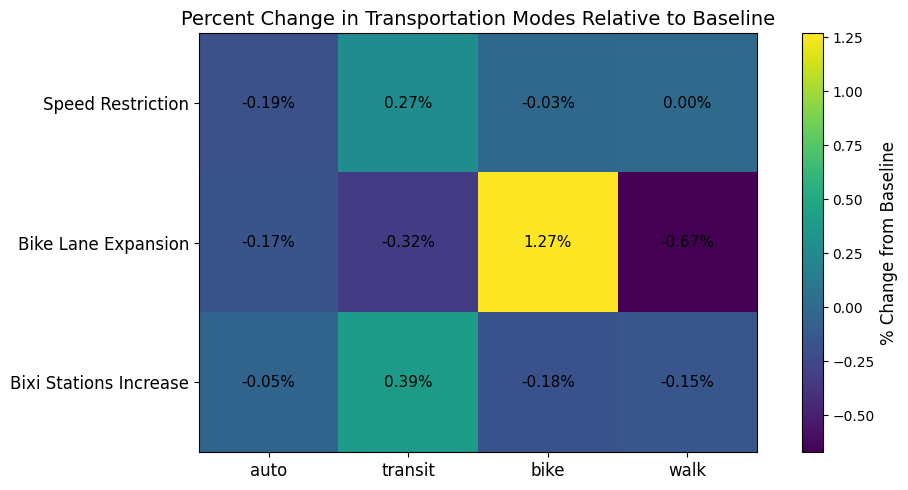

In [ ]:
speed_restriction_results = pd.read_csv("/content/drive/MyDrive/Transportation_UrbanHealth/Auto_speed_restriction_results_50people.csv")
bike_lane_expand_results = pd.read_csv("/content/drive/MyDrive/Transportation_UrbanHealth/Bike_lane_expand_results_50people.csv")
bixi_stations_increases_results = pd.read_csv("/content/drive/MyDrive/Transportation_UrbanHealth/Bixi_stations_extension_results_50people.csv")
baseline_results = pd.read_csv("/content/drive/MyDrive/Transportation_UrbanHealth/Baseline_results_50people.csv")

modes = ['auto', 'transit', 'bike', 'walk']

baseline_means = baseline_results[modes].mean()

scenario_changes = {}

scenario_changes['Speed Restriction'] = ((speed_restriction_results[modes].mean() - baseline_means)/ baseline_means) * 100

scenario_changes['Bike Lane Expansion'] = ((bike_lane_expand_results[modes].mean() - baseline_means)/ baseline_means) * 100

scenario_changes['Bixi Stations Increase'] = ((bixi_stations_increases_results[modes].mean() - baseline_means)/ baseline_means) * 100

heatmap_df = pd.DataFrame(scenario_changes).T

# Plot heatmap

fig, ax = plt.subplots(figsize=(10, 5))

im = ax.imshow(heatmap_df.values)

# Axis labels
ax.set_xticks(np.arange(len(modes)))
ax.set_xticklabels(modes, fontsize=12)

ax.set_yticks(np.arange(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index, fontsize=12)

# Add values inside cells
for i in range(len(heatmap_df.index)):
    for j in range(len(modes)):

        value = heatmap_df.iloc[i, j]

        ax.text(
            j,
            i,
            f"{value:.2f}%",
            ha="center",
            va="center",
            fontsize=11
        )

# Colorbar
cbar = plt.colorbar(im)
cbar.set_label('% Change from Baseline', fontsize=12)

# Title
ax.set_title(
    'Percent Change in Transportation Modes Relative to Baseline',
    fontsize=14
)

plt.tight_layout()

plt.show()

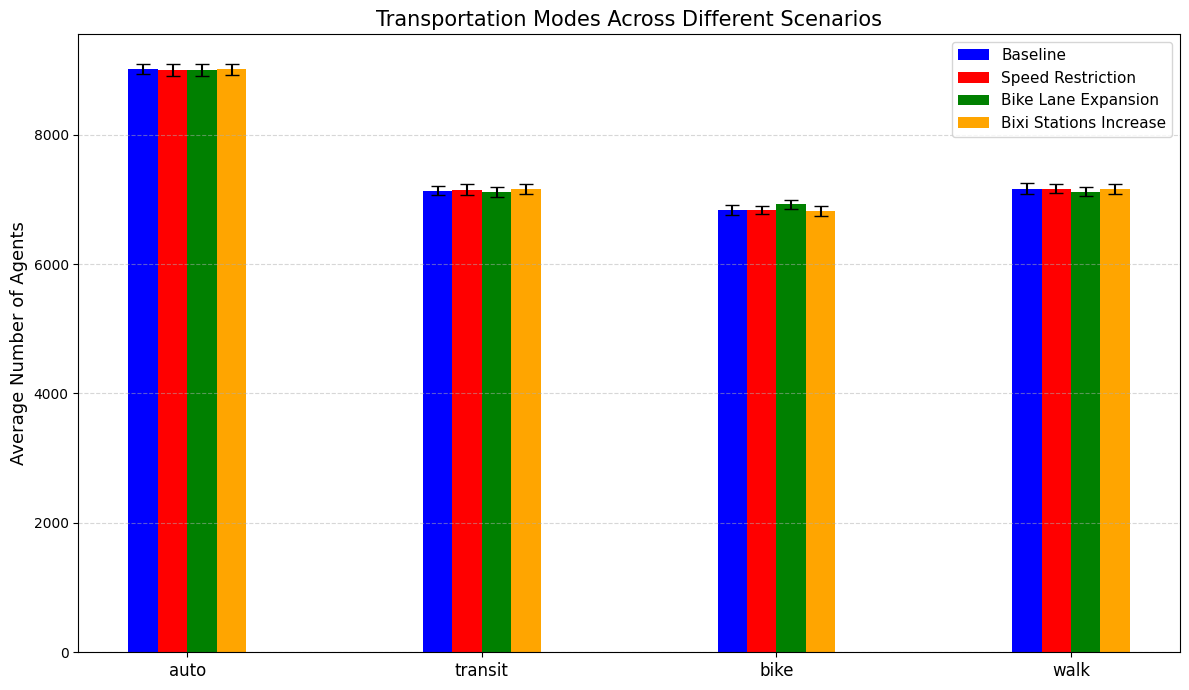

In [ ]:

scenarios = {
    'Baseline': baseline_results,
    'Speed Restriction': speed_restriction_results,
    'Bike Lane Expansion': bike_lane_expand_results,
    'Bixi Stations Increase': bixi_stations_increases_results,
}

modes = ['auto', 'transit', 'bike', 'walk']

colors = ['blue', 'red', 'green', 'orange']

means = {}
stds = {}

for scenario_name, df in scenarios.items():

    means[scenario_name] = [
        df[mode].mean() for mode in modes
    ]

    stds[scenario_name] = [
        df[mode].std() for mode in modes
    ]


x = np.arange(len(modes))
width = 0.1

fig, ax = plt.subplots(figsize=(12,7))

for i, scenario_name in enumerate(scenarios.keys()):

    ax.bar(
        x + i*width,
        means[scenario_name],
        width,
        yerr=stds[scenario_name],
        capsize=5,
        label=scenario_name,
        color=colors[i]
    )

ax.set_xticks(x + width*1.5)
ax.set_xticklabels(modes, fontsize=12)

ax.set_ylabel('Average Number of Agents', fontsize=13)

ax.set_title(
    'Transportation Modes Across Different Scenarios',
    fontsize=15
)

ax.legend(fontsize=11)

ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.show()


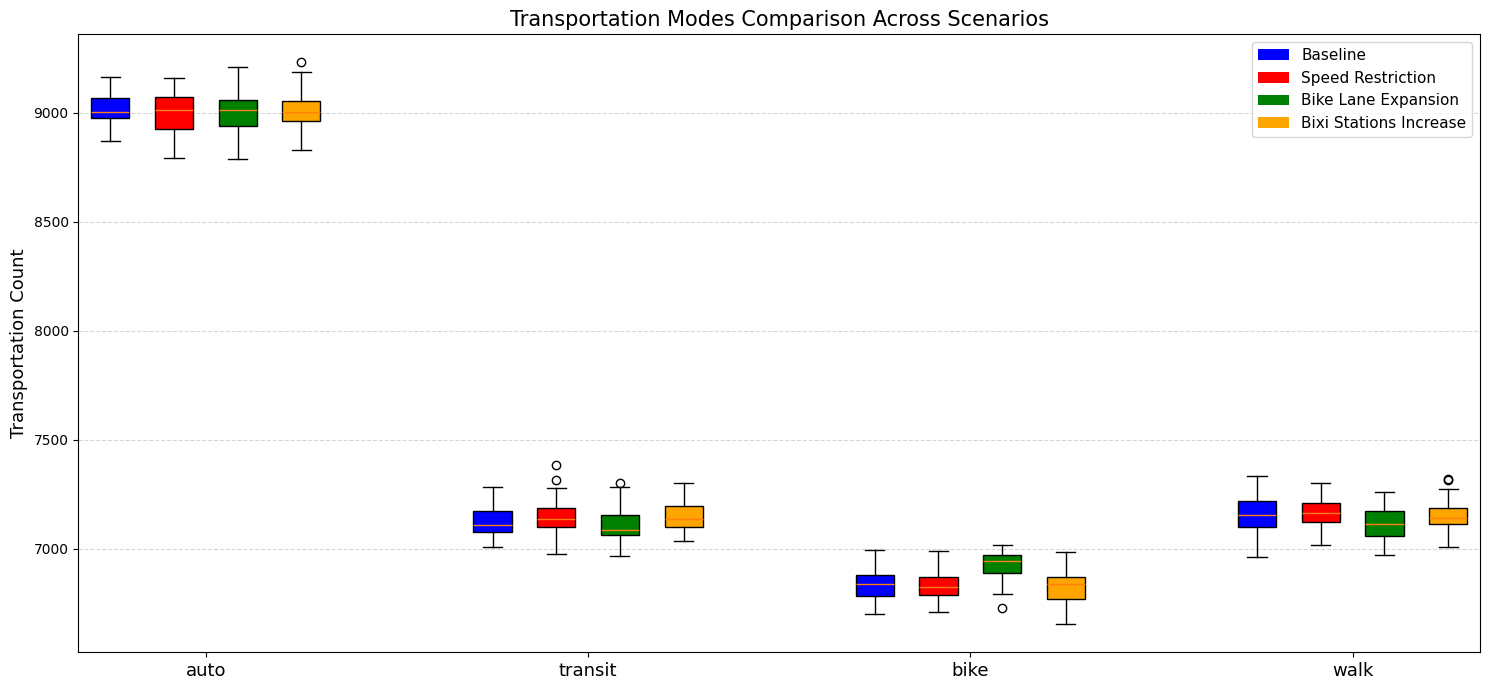

In [ ]:
scenarios = {
    'Baseline': baseline_results,
    'Speed Restriction': speed_restriction_results,
    'Bike Lane Expansion': bike_lane_expand_results,
    'Bixi Stations Increase': bixi_stations_increases_results,
}

modes = ['auto', 'transit', 'bike', 'walk']

colors = ['blue', 'red', 'green', 'orange']


fig, ax = plt.subplots(figsize=(15,7))

positions = []
data = []
box_colors = []

scenario_names = list(scenarios.keys())

# spacing parameters
group_gap = 2
box_width = 0.6

for i, mode in enumerate(modes):

    # Base position for each transportation mode
    base_pos = i * (len(scenarios) + group_gap)

    for j, scenario_name in enumerate(scenario_names):

        pos = base_pos + j

        positions.append(pos)

        data.append(
            scenarios[scenario_name][mode]
        )

        box_colors.append(colors[j])


bp = ax.boxplot(
    data,
    positions=positions,
    widths=box_width,
    patch_artist=True
)

# Color each scenario
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)


mode_centers = [
    i * (len(scenarios) + group_gap) + 1.5
    for i in range(len(modes))
]

ax.set_xticks(mode_centers)
ax.set_xticklabels(modes, fontsize=13)



legend_elements = [
    Patch(facecolor=colors[i], label=scenario_names[i])
    for i in range(len(scenario_names))
]

ax.legend(
    handles=legend_elements,
    fontsize=11,
    loc='upper right'
)


ax.set_ylabel('Transportation Count', fontsize=13)

ax.set_title(
    'Transportation Modes Comparison Across Scenarios',
    fontsize=15
)

ax.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()

plt.show()